In [1]:
import sys
import os

# Add the src directory to sys.path
sys.path.append(os.path.abspath("../src"))

In [2]:
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn, Tensor
from torch.optim import AdamW
from torch.utils.data import DataLoader, TensorDataset

from abstractions.dsl.abstraction import Abstraction
from abstractions.dsl.instantiation import instantiate
from abstractions.dsl.core import Shape
from abstractions.dsl.nodes import Rect, Move, SymTrans, SymRef, Union
from abstractions.learning.utils import add, get_singletons, get_pairs

from abstractions.primitives.visualization import show_boxes, print_tree, visualize_combined_dataset
from abstractions.data.generator import generate_dataset
from abstractions.learning.abstraction_discovery import find_abstractions, integrate_abstractions

import ipywidgets as widgets
import pandas as pd
import plotly.express as px
from IPython.display import display

Union(
    Rect(
        1.000,
        2.000
    ),
    Rect(
        3.000,
        4.000
    )
)


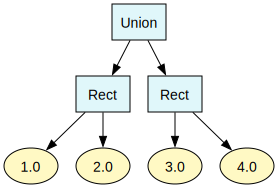

In [3]:
type_list = [Union, Rect, float, float, Rect, float, float]
param_list = [1, 2, 3, 4]
shape = instantiate(type_list, param_list)

print(shape)

print_tree(shape)

In [4]:
show_boxes(shape.get_box_list(), backend="plotly", limits=(-3,3))

In [5]:
dataset = (
    generate_dataset("chair_1", 512) +
    generate_dataset("chair_2", 512) +
    generate_dataset("chair_3", 512)
)

In [ ]:
categories = [
    ("chair_1", 0, 511),
    ("chair_2", 512, 1023),
    ("chair_3", 1024, 1535),
]

visualize_combined_dataset(dataset, categories)

Output()

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from abstractions.data.chair_3 import chair_3
from abstractions.primitives.visualization import show_boxes, print_tree

# Create sliders for all chair parameters
width_slider = widgets.FloatSlider(value=0.8, min=0.3, max=1.5, step=0.05, description='Width:')
leg_height_slider = widgets.FloatSlider(value=0.6, min=0.2, max=1.5, step=0.05, description='Leg Height:')
leg_thickness_slider = widgets.FloatSlider(value=0.1, min=0.05, max=0.3, step=0.01, description='Leg Thickness:')
back_height_slider = widgets.FloatSlider(value=0.8, min=0.3, max=1.5, step=0.05, description='Back Height:')
back_thickness_slider = widgets.FloatSlider(value=0.1, min=0.05, max=0.3, step=0.01, description='Back Thickness:')
seat_thickness_slider = widgets.FloatSlider(value=0.1, min=0.05, max=0.3, step=0.01, description='Seat Thickness:')
armrest_thickness_slider = widgets.FloatSlider(value=0.07, min=0.03, max=0.2, step=0.01, description='Armrest Thickness:')

output = widgets.Output()

def update_visualization(change=None):
    with output:
        clear_output(wait=True)
        chair = chair_3(
            width=width_slider.value,
            leg_height=leg_height_slider.value,
            leg_thickness=leg_thickness_slider.value,
            back_height=back_height_slider.value,
            back_thickness=back_thickness_slider.value,
            seat_thickness=seat_thickness_slider.value,
            armrest_thickness=armrest_thickness_slider.value,
        )
        print_tree(chair)
        show_boxes(chair.get_box_list(), backend="plotly")

# Observe all sliders
for slider in [
    width_slider,
    leg_height_slider,
    leg_thickness_slider,
    back_height_slider,
    back_thickness_slider,
    seat_thickness_slider,
    armrest_thickness_slider,
]:
    slider.observe(update_visualization, names='value')

# Display sliders and output
display(
    widgets.VBox([
        width_slider,
        leg_height_slider,
        leg_thickness_slider,
        back_height_slider,
        back_thickness_slider,
        seat_thickness_slider,
        armrest_thickness_slider,
    ]),
    output,
)

# Initial visualization
update_visualization()

Output()

In [8]:
def extract_float_params(shape):
    """
    Recursively extract all float parameters from a shape.

    Parameters
    ----------
    shape : Shape
        Shape object with possible nested children.

    Returns
    -------
    list of float
        Flattened list of all float parameters in the shape.
    """
    floats = []

    def recurse(node):
        # param_tuple returns (type, tuple_of_params)
        _, params = node.param_tuple()

        for p in params:
            if isinstance(p, float):
                floats.append(p)
            elif isinstance(p, Shape):
                recurse(p)
            # ignore ints, str, or other types here

    recurse(shape)
    return floats

In [9]:
sample_params = extract_float_params(dataset[0])
print(f"Extracted {len(sample_params)} float parameters from shape 0")
print(sample_params)

Extracted 10 float parameters from shape 0
[0.2, 0.325, -0.35, 0.2, 0.9, 0.07500000000000001, 0.125, 0.925, 0.3875, -0.5]


In [10]:
import numpy as np

X = [extract_float_params(shape) for shape in dataset]

# Shapes may have different lengths (rare). Let's pad or truncate to fixed length.
max_len = max(len(x) for x in X)
X_padded = np.array([x + [0]*(max_len - len(x)) if len(x) < max_len else x[:max_len] for x in X])

In [12]:
from sklearn.cluster import KMeans

n_clusters = 5  # choose based on your knowledge or experiment
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(X_padded)

print(f"Cluster assignments for first 10 shapes: {labels[:10]}")

Cluster assignments for first 10 shapes: [2 2 2 2 2 2 2 2 2 2]


In [13]:
# For example, save as a dictionary or list for indexing shapes by cluster
shape_clusters = {i: [] for i in range(n_clusters)}
for idx, label in enumerate(labels):
    shape_clusters[label].append(dataset[idx])

In [14]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, random_state=42)
X_embedded = tsne.fit_transform(X_padded)

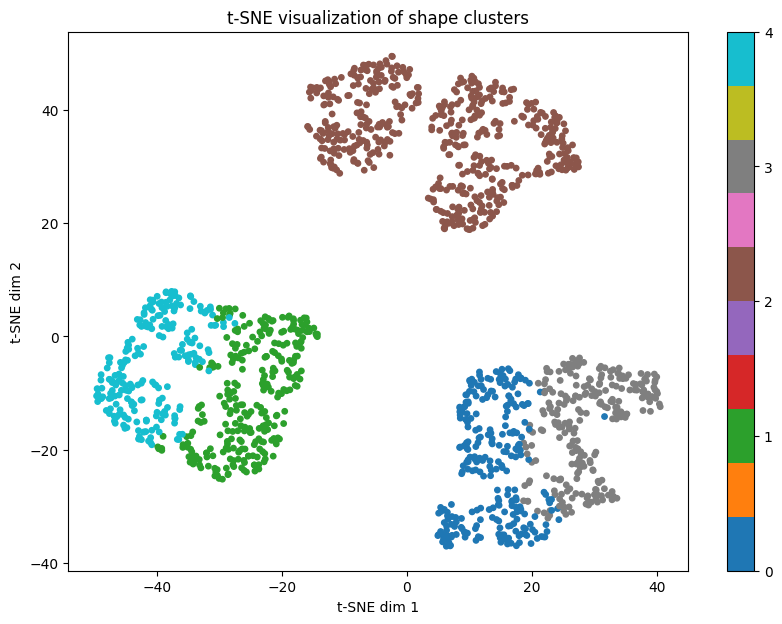

In [15]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=labels, cmap='tab10', s=15)
plt.colorbar(scatter, ticks=range(n_clusters))
plt.title("t-SNE visualization of shape clusters")
plt.xlabel("t-SNE dim 1")
plt.ylabel("t-SNE dim 2")
plt.show()


Cluster 0 samples:


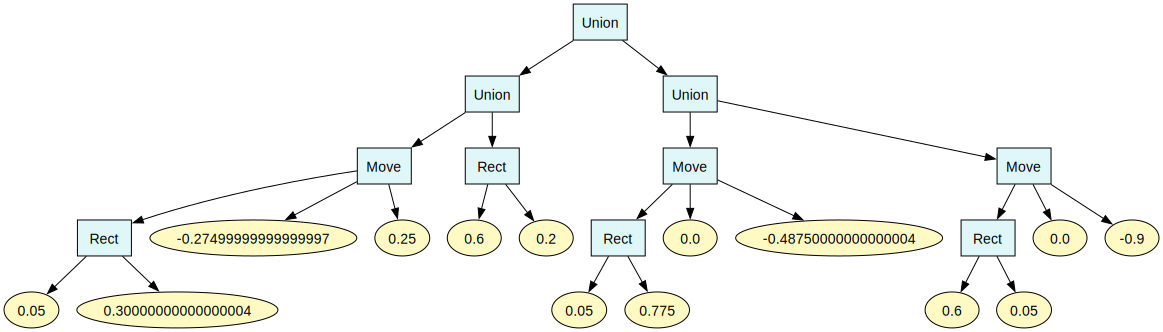

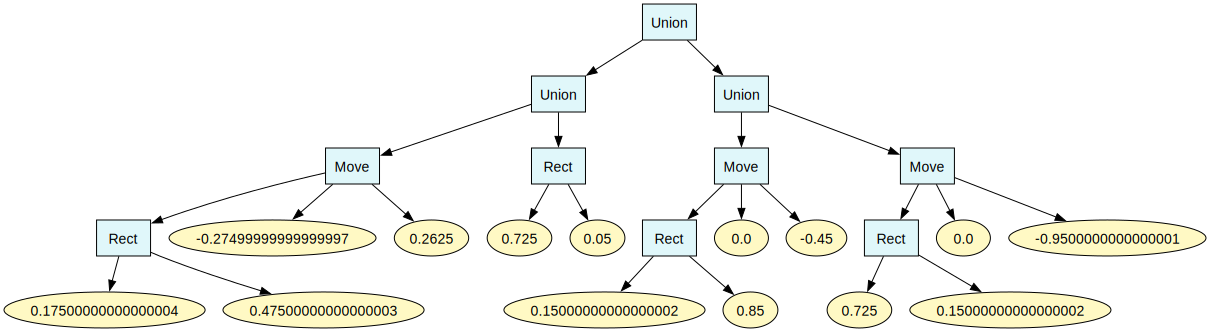

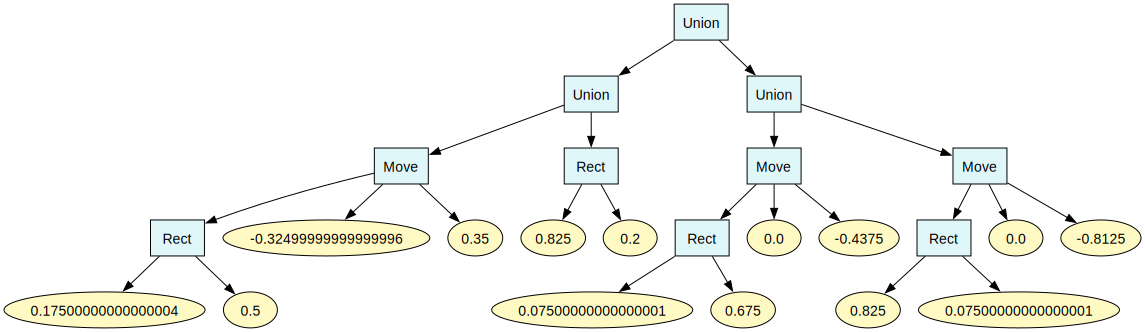


Cluster 1 samples:


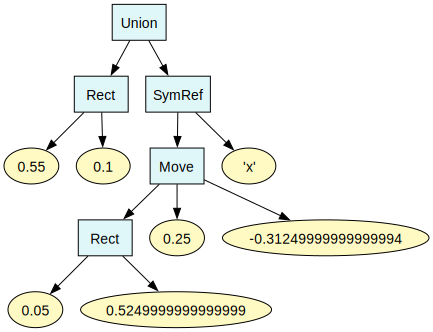

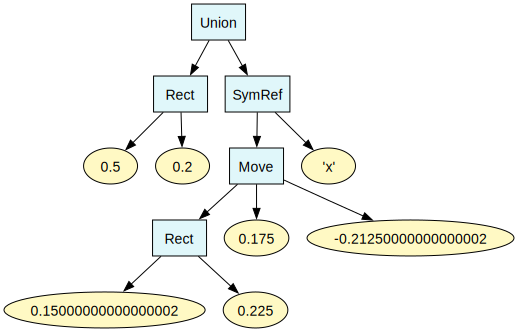

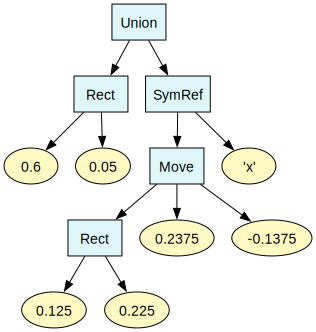


Cluster 2 samples:


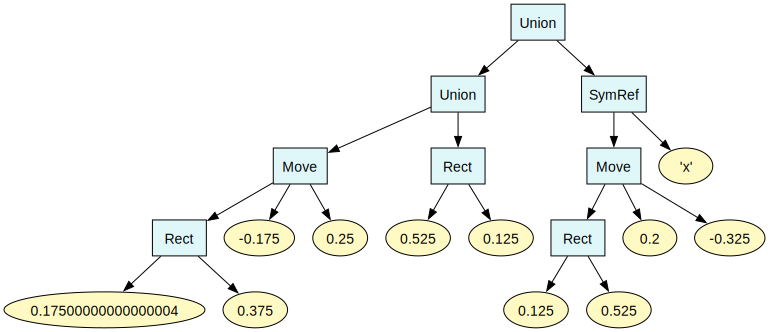

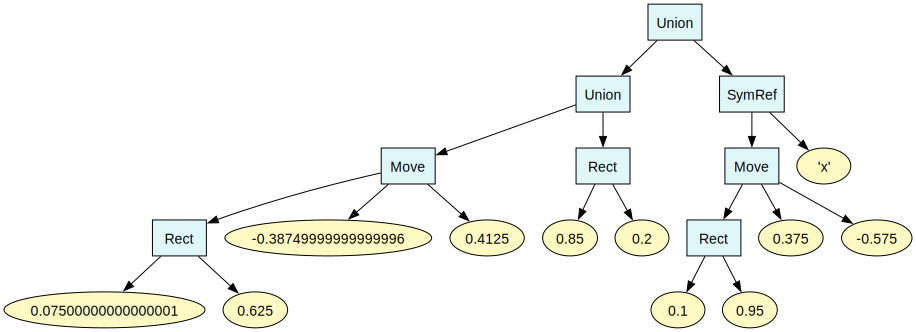

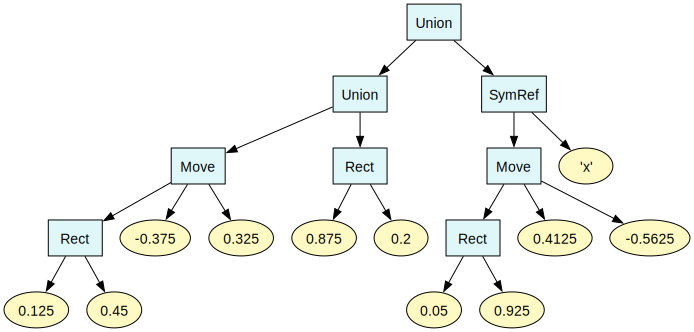


Cluster 3 samples:


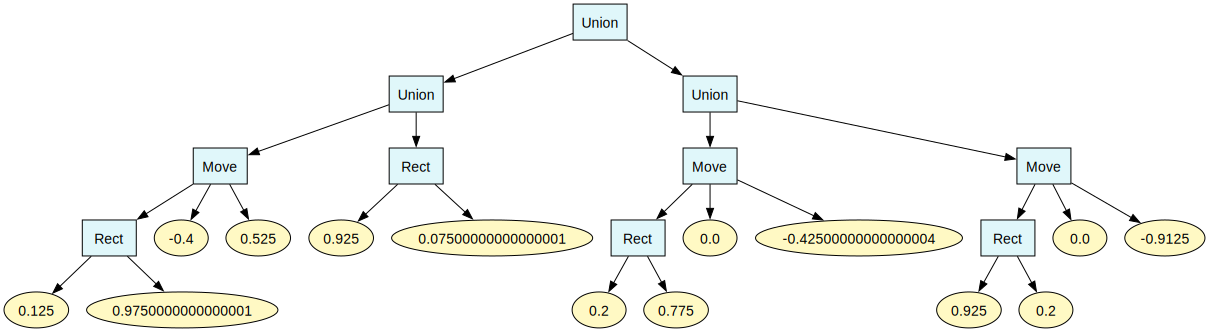

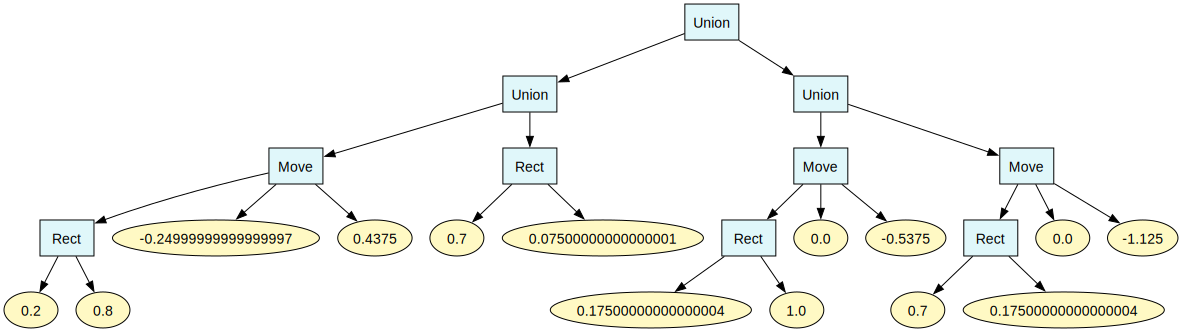

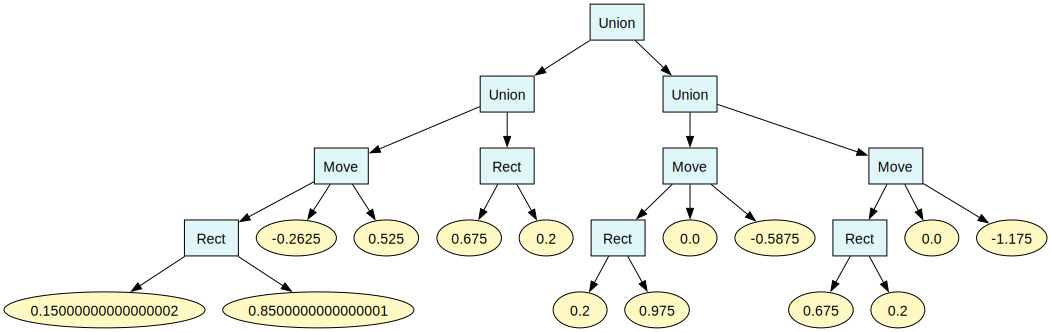


Cluster 4 samples:


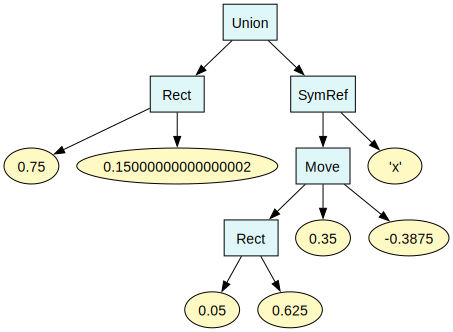

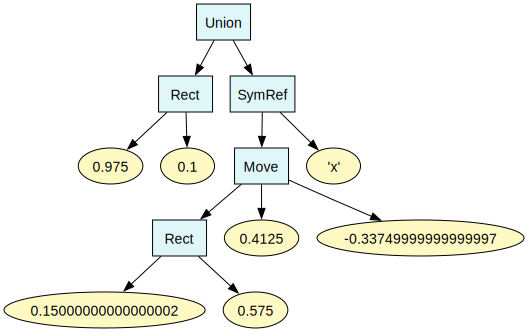

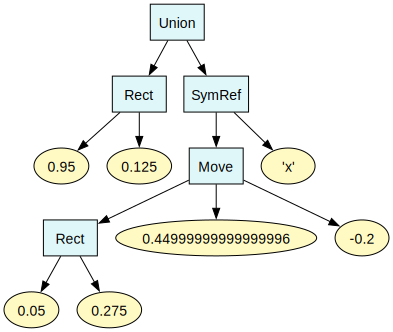

In [16]:
import random

for cluster_id in range(n_clusters):
    print(f"\nCluster {cluster_id} samples:")
    samples = random.sample(shape_clusters[cluster_id], min(3, len(shape_clusters[cluster_id])))
    for s in samples:
        display(print_tree(s))

In [17]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def visualize_clusters(dataset, labels):
    """
    Interactive widget to explore clusters and their shapes.

    Parameters
    ----------
    dataset : list
        List of shape objects.
    labels : list or np.array
        Cluster labels for each shape.

    Returns
    -------
    None
        Displays widgets in notebook.
    """
    import numpy as np
    cluster_ids = sorted(set(labels))
    cluster_to_indices = {cid: np.where(labels == cid)[0].tolist() for cid in cluster_ids}

    cluster_dropdown = widgets.Dropdown(
        options=cluster_ids,
        description="Cluster:"
    )
    index_slider = widgets.IntSlider(min=0, max=0, step=1, description="Index:")
    output = widgets.Output()

    def update_index_range(change):
        cluster = change['new']
        indices = cluster_to_indices[cluster]
        index_slider.min = 0
        index_slider.max = len(indices) - 1
        index_slider.value = 0

    def update_visualization(change=None):
        output.clear_output()
        with output:
            cluster = cluster_dropdown.value
            idx = index_slider.value
            shape_idx = cluster_to_indices[cluster][idx]
            shape = dataset[shape_idx]
            display(print_tree(shape))
            show_boxes(shape.get_box_list(), backend="plotly")

    cluster_dropdown.observe(update_index_range, names='value')
    cluster_dropdown.observe(update_visualization, names='value')
    index_slider.observe(update_visualization, names='value')

    display(widgets.VBox([cluster_dropdown, index_slider]), output)

    # Initialize display
    cluster_dropdown.value = cluster_ids[0]
    update_visualization()

In [18]:
visualize_clusters(dataset, labels)

Output()

In [19]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
import pandas as pd

def evaluate_clusters(X, label_sets, verbose=True):
    """
    Compute silhouette and Davies-Bouldin scores for multiple clusterings.

    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Feature matrix.
    label_sets : dict or list
        If dict, keys are names, values are label arrays.
        If list, label arrays only (names auto-generated).
    verbose : bool
        If True, print results table.

    Returns
    -------
    pd.DataFrame
        DataFrame with columns: ['method', 'silhouette', 'davies_bouldin'].
    """
    results = []
    if isinstance(label_sets, dict):
        items = label_sets.items()
    else:
        items = [(f"Method {i+1}", labels) for i, labels in enumerate(label_sets)]

    for name, labels in items:
        sil = silhouette_score(X, labels)
        db = davies_bouldin_score(X, labels)
        results.append({"method": name, "silhouette": sil, "davies_bouldin": db})

    df = pd.DataFrame(results)
    if verbose:
        print(df)
    return df

In [21]:
# Suppose you ran two clusterings:
labels_kmeans = kmeans.labels_
#labels_dbscan = dbscan.labels_

evaluate_clusters(X_padded, {
    "KMeans": labels_kmeans,
    #"DBSCAN": labels_dbscan
})

   method  silhouette  davies_bouldin
0  KMeans    0.393286        1.236385


,method,silhouette,davies_bouldin
0,KMeans,0.393286,1.236385


In [22]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
import pandas as pd

def run_multiple_clusterings(X, cluster_configs):
    """
    Runs multiple clustering algorithms and evaluates them.

    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Feature matrix.
    cluster_configs : list of tuples
        Each tuple contains (name:str, clustering_instance).

    Returns
    -------
    pd.DataFrame
        DataFrame summarizing the cluster quality metrics.
    dict
        Dictionary mapping method names to cluster labels.
    """
    results = []
    labels_dict = {}

    for name, clusterer in cluster_configs:
        labels = clusterer.fit_predict(X)
        labels_dict[name] = labels
        sil = silhouette_score(X, labels) if len(set(labels)) > 1 else float('nan')
        db = davies_bouldin_score(X, labels) if len(set(labels)) > 1 else float('nan')
        results.append({'method': name, 'silhouette': sil, 'davies_bouldin': db})

    df = pd.DataFrame(results)
    return df, labels_dict

# Example usage:
cluster_configs = [
    ('KMeans_5', KMeans(n_clusters=5, random_state=42)),
    ('DBSCAN_0.5', DBSCAN(eps=0.5, min_samples=5)),
    ('Agglomerative_5', AgglomerativeClustering(n_clusters=5))
]

df_results, labels_dict = run_multiple_clusterings(X_padded, cluster_configs)
print(df_results)

            method  silhouette  davies_bouldin
0         KMeans_5    0.393286        1.236385
1       DBSCAN_0.5    0.653129        0.570943
2  Agglomerative_5    0.421404        1.282538


In [32]:
cluster_to_indices = {cid: np.where(labels == cid)[0].tolist() for cid in set(labels)}

Processing cluster 0 with 266 shapes
  Structure: Union | Count: 798 | Sample Params: (<abstractions.dsl.nodes.Move object at 0x132d17b90>, <abstractions.dsl.nodes.Rect object at 0x132d17bf0>)
  Structure: Move | Count: 798 | Sample Params: (<abstractions.dsl.nodes.Rect object at 0x132d17980>, 0.0, -0.44999999999999996)
  Structure: Rect | Count: 1064 | Sample Params: (0.05, 0.30000000000000004)
  Structure: Union(Move, Move) | Count: 266 | Sample Params: (<abstractions.dsl.nodes.Rect object at 0x132d1c350>, 0.0, -0.375, <abstractions.dsl.nodes.Rect object at 0x132d1c410>, 0.0, -0.7374999999999999)
  Structure: Union(Move, Rect) | Count: 266 | Sample Params: (<abstractions.dsl.nodes.Rect object at 0x132d1c500>, -0.28750000000000003, 0.275, 0.675, 0.17500000000000004)
  Structure: Union(Union, Union) | Count: 266 | Sample Params: (<abstractions.dsl.nodes.Move object at 0x132d1c560>, <abstractions.dsl.nodes.Rect object at 0x132d1c5c0>, <abstractions.dsl.nodes.Move object at 0x132d1c3b0>,

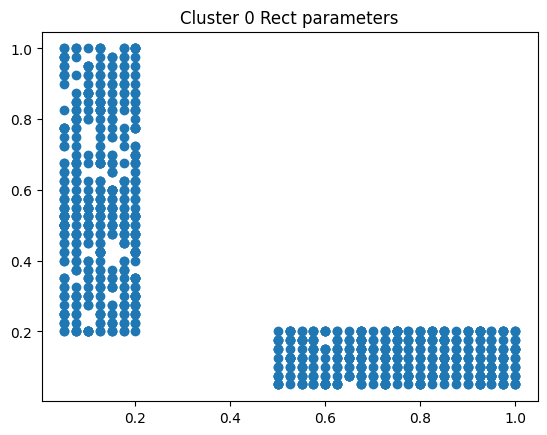

Iteration 1/4: training model for Move on 798 structures.
Iteration 2/4: training model for Move on 569 structures.
Iteration 3/4: training model for Move on 567 structures.
Iteration 4/4: training model for Move on 566 structures.
Trained model for Move. Final train loss: 0.0044393148661280675
Iteration 1/4: training model for Rect on 1064 structures.
Iteration 2/4: training model for Rect on 133 structures.
Iteration 3/4: training model for Rect on 141 structures.
Iteration 4/4: training model for Rect on 75 structures.
Trained model for Rect. Final train loss: 0.00882895477116108
Iteration 1/4: training model for Union(Move, Move) on 266 structures.
Iteration 2/4: training model for Union(Move, Move) on 39 structures.
Iteration 3/4: training model for Union(Move, Move) on 43 structures.
Iteration 4/4: training model for Union(Move, Move) on 1 structures.
Trained model for Union(Move, Move). Final train loss: 0.006987214088439941
Iteration 1/4: training model for Union(Move, Rect) on

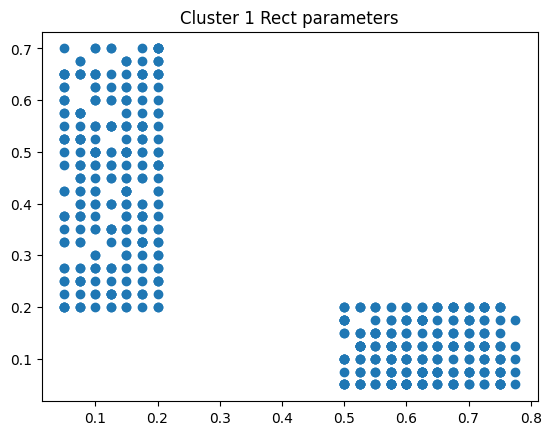

Iteration 1/4: training model for Rect on 574 structures.
Iteration 2/4: training model for Rect on 63 structures.
Iteration 3/4: training model for Rect on 30 structures.
Iteration 4/4: training model for Rect on 3 structures.
Trained model for Rect. Final train loss: 0.0013106862315908074
Iteration 1/4: training model for Move on 287 structures.
Iteration 2/4: training model for Move on 46 structures.
Iteration 3/4: training model for Move on 2 structures.
Iteration 4/4: training model for Move on 2 structures.
Trained model for Move. Final train loss: 0.0011816620826721191
Iteration 1/4: training model for Union(Rect, SymRef) on 287 structures.
Iteration 2/4: training model for Union(Rect, SymRef) on 46 structures.
Iteration 3/4: training model for Union(Rect, SymRef) on 5 structures.
Iteration 4/4: training model for Union(Rect, SymRef) on 5 structures.
Trained model for Union(Rect, SymRef). Final train loss: 0.09374278783798218
Processing cluster 2 with 512 shapes
  Structure: Uni

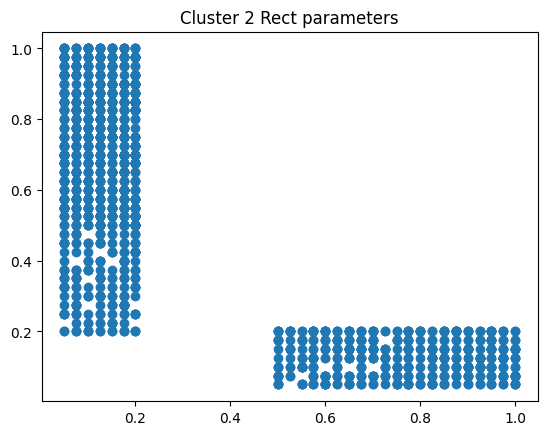

Iteration 1/4: training model for Move on 1024 structures.
Iteration 2/4: training model for Move on 84 structures.
Iteration 3/4: training model for Move on 84 structures.
Iteration 4/4: training model for Move on 88 structures.
Trained model for Move. Final train loss: 0.00719426991418004
Iteration 1/4: training model for Rect on 1536 structures.
Iteration 2/4: training model for Rect on 202 structures.
Iteration 3/4: training model for Rect on 204 structures.
Iteration 4/4: training model for Rect on 181 structures.
Trained model for Rect. Final train loss: 0.011054811999201775
Iteration 1/4: training model for Union(Move, Rect) on 512 structures.
Iteration 2/4: training model for Union(Move, Rect) on 16 structures.
Iteration 3/4: training model for Union(Move, Rect) on 1 structures.
Iteration 4/4: training model for Union(Move, Rect) on 1 structures.
Trained model for Union(Move, Rect). Final train loss: 0.011053420603275299
Processing cluster 3 with 246 shapes
  Structure: Union |

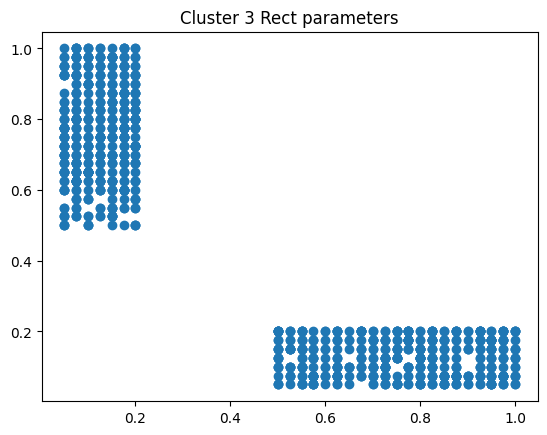

Iteration 1/4: training model for Move on 738 structures.
Iteration 2/4: training model for Move on 405 structures.
Iteration 3/4: training model for Move on 541 structures.
Iteration 4/4: training model for Move on 493 structures.
Trained model for Move. Final train loss: 0.0031572625739499927
Iteration 1/4: training model for Rect on 984 structures.
Iteration 2/4: training model for Rect on 98 structures.
Iteration 3/4: training model for Rect on 72 structures.
Iteration 4/4: training model for Rect on 57 structures.
Trained model for Rect. Final train loss: 0.0881706029176712
Iteration 1/4: training model for Union(Move, Move) on 246 structures.
Iteration 2/4: training model for Union(Move, Move) on 140 structures.
Iteration 3/4: training model for Union(Move, Move) on 52 structures.
Iteration 4/4: training model for Union(Move, Move) on 7 structures.
Trained model for Union(Move, Move). Final train loss: 0.011100603267550468
Iteration 1/4: training model for Union(Move, Rect) on 24

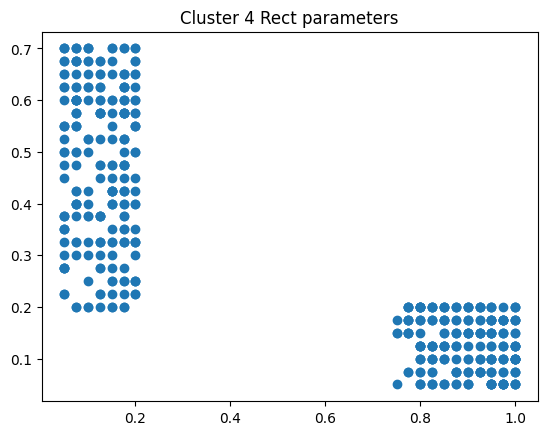

Iteration 1/4: training model for Rect on 450 structures.
Iteration 2/4: training model for Rect on 29 structures.
Iteration 3/4: training model for Rect on 23 structures.
Iteration 4/4: training model for Rect on 3 structures.
Trained model for Rect. Final train loss: 0.0017944574356079102
Iteration 1/4: training model for Move on 225 structures.
Iteration 2/4: training model for Move on 52 structures.
Iteration 3/4: training model for Move on 2 structures.
Iteration 4/4: training model for Move on 2 structures.
Trained model for Move. Final train loss: 0.006230801343917847
Iteration 1/4: training model for Union(Rect, SymRef) on 225 structures.
Iteration 2/4: training model for Union(Rect, SymRef) on 4 structures.
Iteration 3/4: training model for Union(Rect, SymRef) on 3 structures.
Iteration 4/4: training model for Union(Rect, SymRef) on 3 structures.
Trained model for Union(Rect, SymRef). Final train loss: 0.011416494846343994


In [33]:
for cluster_id, indices in cluster_to_indices.items():
    print(f"Processing cluster {cluster_id} with {len(indices)} shapes")

    cluster_dataset = [dataset[i] for i in indices]

    singletons = get_singletons(cluster_dataset)
    pairs = get_pairs(cluster_dataset)
    structures = add(singletons, pairs)

    # Optional: inspect
    for key, instances in structures.items():
        print(f"  Structure: {key} | Count: {len(instances)} | Sample Params: {instances[4]}")

    # Visualize one structure, e.g. Rect
    if "Rect" in structures:
        import matplotlib.pyplot as plt
        plt.figure()
        plt.scatter([s[0] for s in structures["Rect"]], [s[1] for s in structures["Rect"]])
        plt.title(f"Cluster {cluster_id} Rect parameters")
        plt.show()

    # Train abstraction models for this cluster's structures
    models, losses = find_abstractions(structures, retrain_iterations=4, error_threshold=0.01)

    # Store or save models and losses per cluster
    cluster_models[cluster_id] = models
    cluster_losses[cluster_id] = losses

In [34]:
cluster_models = {}
cluster_losses = {}

for cluster_id, indices in cluster_to_indices.items():
    cluster_dataset = [dataset[i] for i in indices]
    singletons = get_singletons(cluster_dataset)
    pairs = get_pairs(cluster_dataset)
    structures = add(singletons, pairs)

    models, losses = find_abstractions(structures, retrain_iterations=4, error_threshold=0.01)

    cluster_models[cluster_id] = models
    cluster_losses[cluster_id] = losses

Iteration 1/4: training model for Move on 798 structures.
Iteration 2/4: training model for Move on 558 structures.
Iteration 3/4: training model for Move on 563 structures.
Iteration 4/4: training model for Move on 438 structures.
Trained model for Move. Final train loss: 0.004908991578434195
Iteration 1/4: training model for Rect on 1064 structures.
Iteration 2/4: training model for Rect on 121 structures.
Iteration 3/4: training model for Rect on 77 structures.
Iteration 4/4: training model for Rect on 87 structures.
Trained model for Rect. Final train loss: 0.007424831390380859
Iteration 1/4: training model for Union(Move, Move) on 266 structures.
Iteration 2/4: training model for Union(Move, Move) on 139 structures.
Iteration 3/4: training model for Union(Move, Move) on 106 structures.
Iteration 4/4: training model for Union(Move, Move) on 111 structures.
Trained model for Union(Move, Move). Final train loss: 0.008959949715062976
Iteration 1/4: training model for Union(Move, Rect)

Processing cluster 0 with 266 shapes
Iteration 1/4: training model for Move on 798 structures.
Iteration 2/4: training model for Move on 573 structures.
Iteration 3/4: training model for Move on 570 structures.
Iteration 4/4: training model for Move on 1 structures.
Trained model for Move. Final train loss: 0.0017182528972625732
Iteration 1/4: training model for Rect on 1064 structures.
Iteration 2/4: training model for Rect on 128 structures.
Iteration 3/4: training model for Rect on 150 structures.
Iteration 4/4: training model for Rect on 163 structures.
Trained model for Rect. Final train loss: 0.009900126295785109
Iteration 1/4: training model for Union(Move, Move) on 266 structures.
Iteration 2/4: training model for Union(Move, Move) on 109 structures.
Iteration 3/4: training model for Union(Move, Move) on 22 structures.
Iteration 4/4: training model for Union(Move, Move) on 10 structures.
Trained model for Union(Move, Move). Final train loss: 0.011208891868591309
Iteration 1/4: 

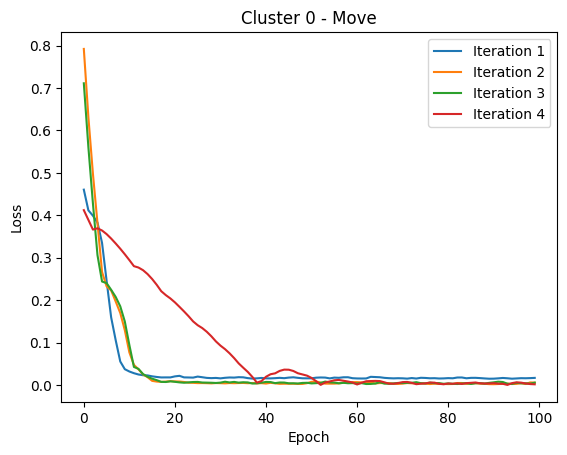

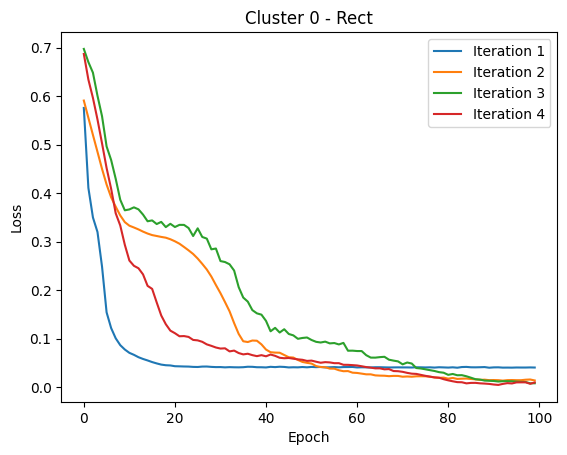

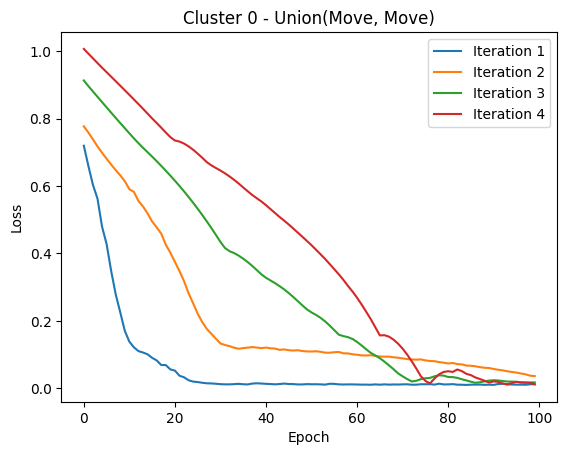

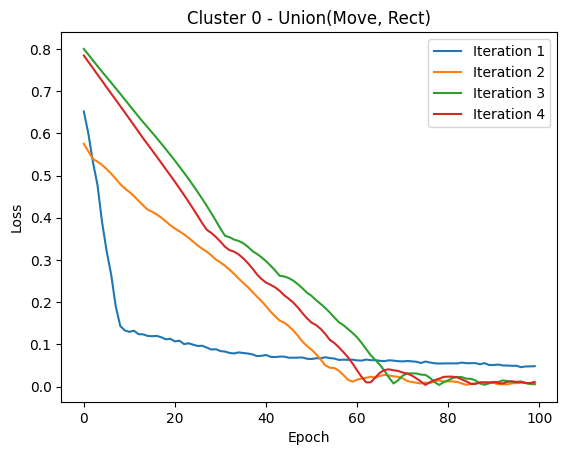

Processing cluster 1 with 287 shapes
Iteration 1/4: training model for Rect on 574 structures.
Iteration 2/4: training model for Rect on 66 structures.
Iteration 3/4: training model for Rect on 15 structures.
Iteration 4/4: training model for Rect on 3 structures.
Trained model for Rect. Final train loss: 0.0005490779876708984
Iteration 1/4: training model for Move on 287 structures.
Iteration 2/4: training model for Move on 57 structures.
Iteration 3/4: training model for Move on 3 structures.
Iteration 4/4: training model for Move on 3 structures.
Trained model for Move. Final train loss: 0.005557159427553415
Iteration 1/4: training model for Union(Rect, SymRef) on 287 structures.
Iteration 2/4: training model for Union(Rect, SymRef) on 40 structures.
Iteration 3/4: training model for Union(Rect, SymRef) on 4 structures.
Iteration 4/4: training model for Union(Rect, SymRef) on 4 structures.
Trained model for Union(Rect, SymRef). Final train loss: 0.007153749465942383


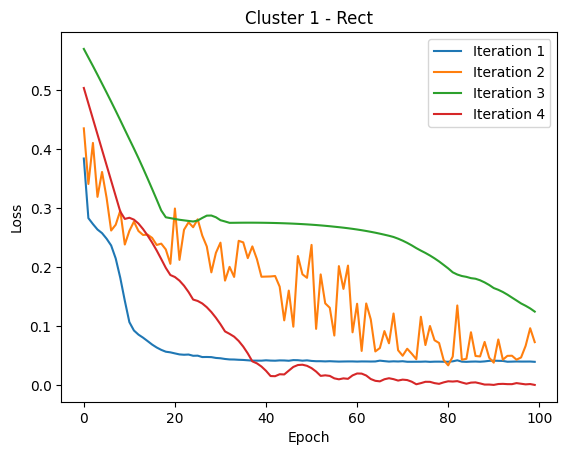

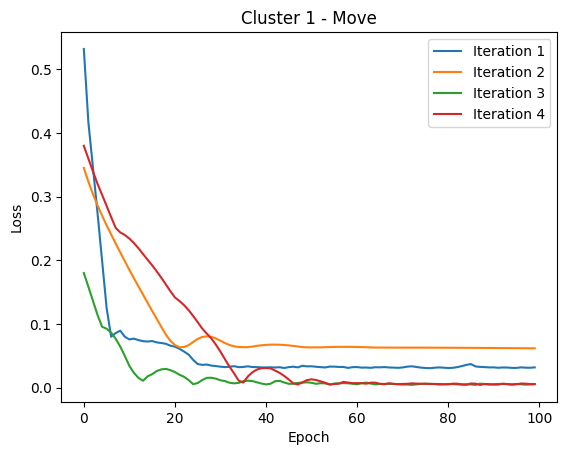

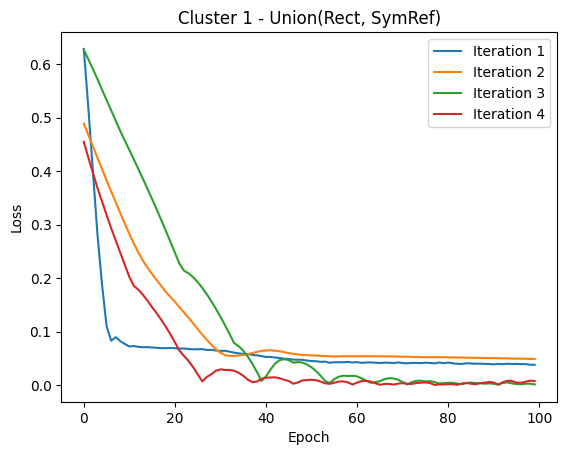

Processing cluster 2 with 512 shapes
Iteration 1/4: training model for Move on 1024 structures.
Iteration 2/4: training model for Move on 107 structures.
Iteration 3/4: training model for Move on 52 structures.
Iteration 4/4: training model for Move on 4 structures.
Trained model for Move. Final train loss: 0.006523601710796356
Iteration 1/4: training model for Rect on 1536 structures.
Iteration 2/4: training model for Rect on 61 structures.
Iteration 3/4: training model for Rect on 9 structures.
Iteration 4/4: training model for Rect on 8 structures.
Trained model for Rect. Final train loss: 0.0038334429264068604
Iteration 1/4: training model for Union(Move, Rect) on 512 structures.
Iteration 2/4: training model for Union(Move, Rect) on 9 structures.
Iteration 3/4: training model for Union(Move, Rect) on 1 structures.
Iteration 4/4: training model for Union(Move, Rect) on 1 structures.
Trained model for Union(Move, Rect). Final train loss: 0.004184454679489136


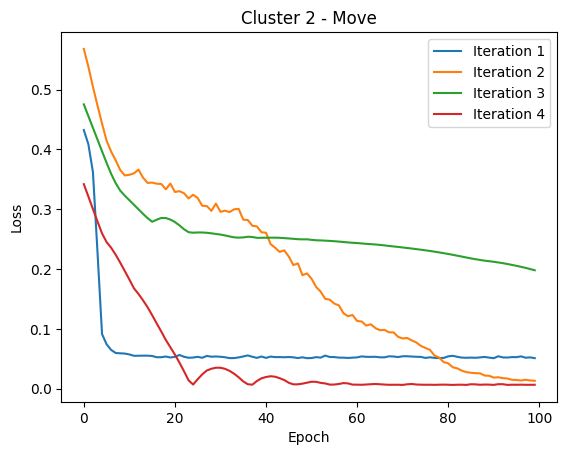

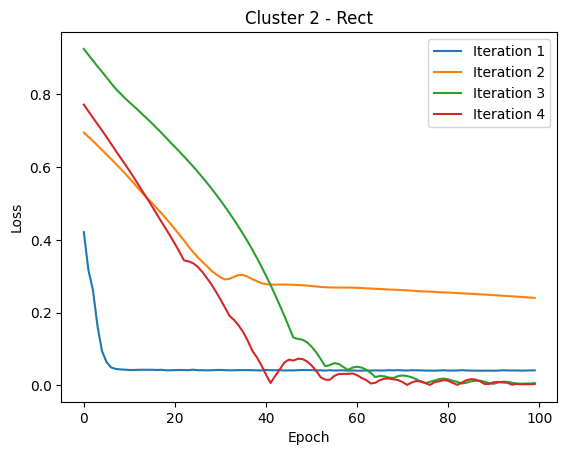

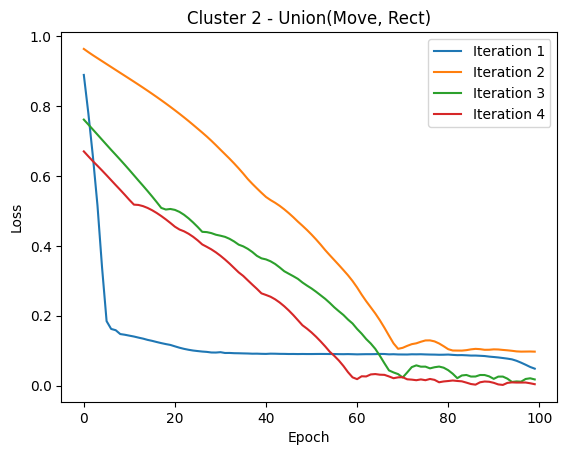

Processing cluster 3 with 246 shapes
Iteration 1/4: training model for Move on 738 structures.
Iteration 2/4: training model for Move on 494 structures.
Iteration 3/4: training model for Move on 510 structures.
Iteration 4/4: training model for Move on 506 structures.
Trained model for Move. Final train loss: 0.003104704082943499
Iteration 1/4: training model for Rect on 984 structures.
Iteration 2/4: training model for Rect on 88 structures.
Iteration 3/4: training model for Rect on 84 structures.
Iteration 4/4: training model for Rect on 54 structures.
Trained model for Rect. Final train loss: 0.13042707741260529
Iteration 1/4: training model for Union(Move, Move) on 246 structures.
Iteration 2/4: training model for Union(Move, Move) on 118 structures.
Iteration 3/4: training model for Union(Move, Move) on 67 structures.
Iteration 4/4: training model for Union(Move, Move) on 1 structures.
Trained model for Union(Move, Move). Final train loss: 0.002787034958600998
Iteration 1/4: train

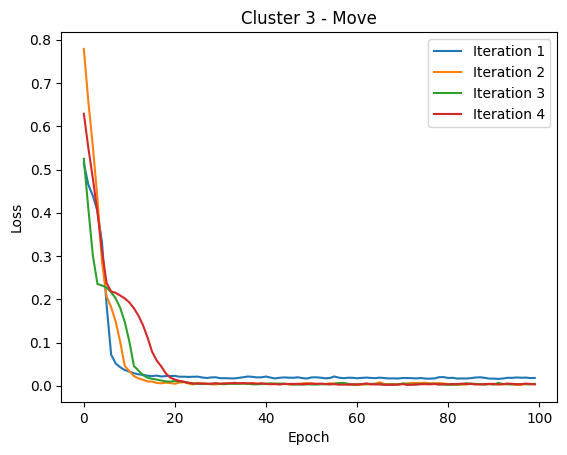

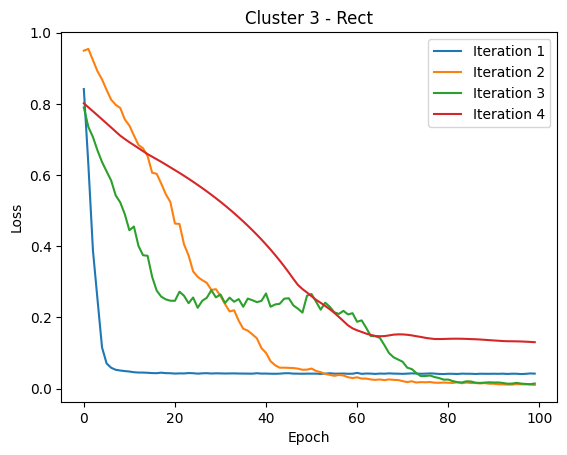

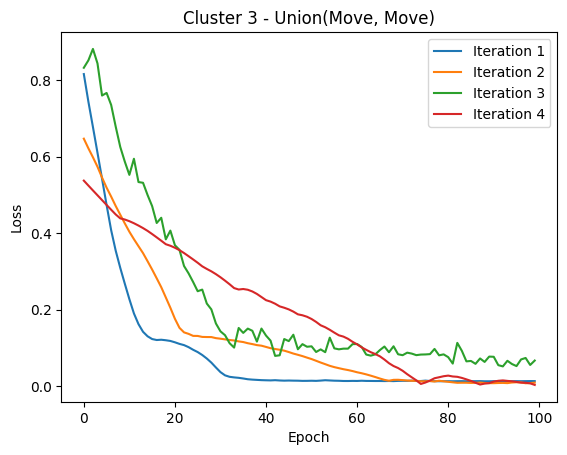

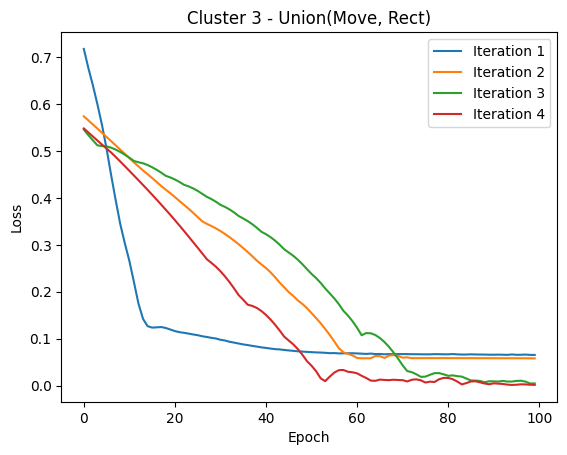

Processing cluster 4 with 225 shapes
Iteration 1/4: training model for Rect on 450 structures.
Iteration 2/4: training model for Rect on 51 structures.
Iteration 3/4: training model for Rect on 22 structures.
Iteration 4/4: training model for Rect on 5 structures.
Trained model for Rect. Final train loss: 0.005215182900428772
Iteration 1/4: training model for Move on 225 structures.
Iteration 2/4: training model for Move on 45 structures.
Iteration 3/4: training model for Move on 1 structures.
Iteration 4/4: training model for Move on 2 structures.
Trained model for Move. Final train loss: 0.006286129355430603
Iteration 1/4: training model for Union(Rect, SymRef) on 225 structures.
Iteration 2/4: training model for Union(Rect, SymRef) on 29 structures.
Iteration 3/4: training model for Union(Rect, SymRef) on 5 structures.
Iteration 4/4: training model for Union(Rect, SymRef) on 5 structures.
Trained model for Union(Rect, SymRef). Final train loss: 0.006191748194396496


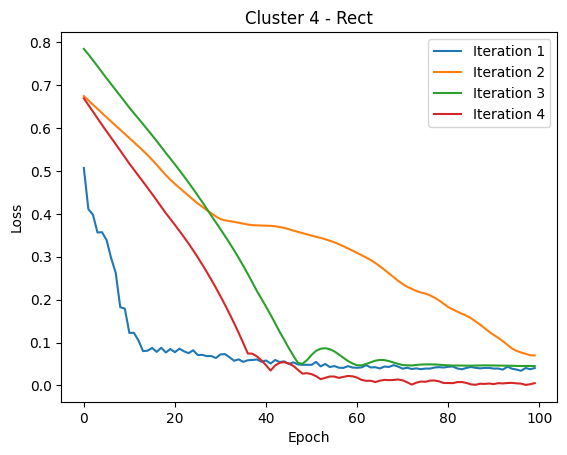

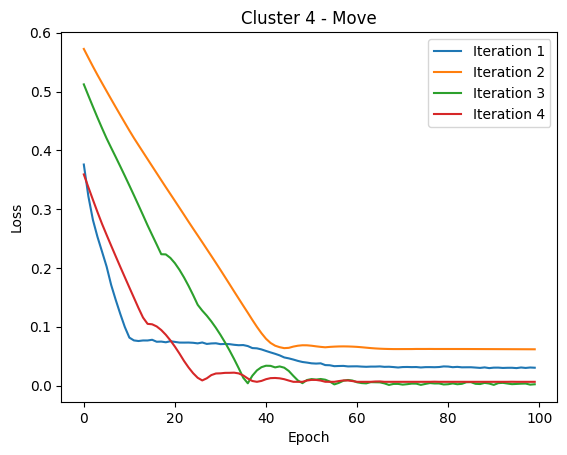

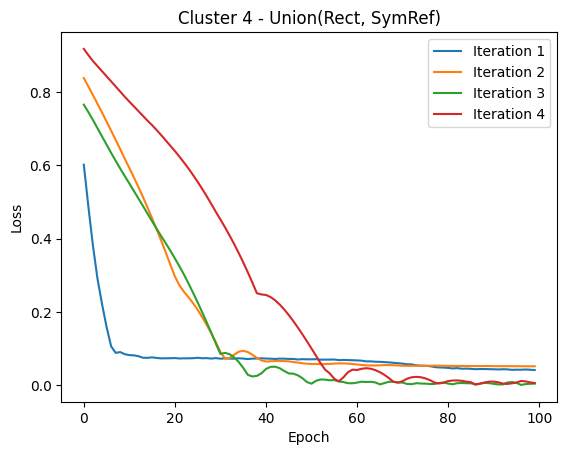

In [37]:
import matplotlib.pyplot as plt

cluster_models = {}
cluster_losses = {}

for cluster_id, indices in cluster_to_indices.items():
    print(f"Processing cluster {cluster_id} with {len(indices)} shapes")

    cluster_dataset = [dataset[i] for i in indices]

    singletons = get_singletons(cluster_dataset)
    pairs = get_pairs(cluster_dataset)
    structures = add(singletons, pairs)

    models, losses = find_abstractions(structures, retrain_iterations=4, error_threshold=0.01)

    cluster_models[cluster_id] = models
    cluster_losses[cluster_id] = losses

    # Plot losses per structure in this cluster
    for structure_name, loss_list in losses.items():
        plt.figure()
        for i in range(len(loss_list)):
            plt.plot(loss_list[i], label=f"Iteration {i+1}")
        plt.legend()
        plt.title(f"Cluster {cluster_id} - {structure_name}")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
    plt.show()

In [41]:
refined_dataset = []

for cluster_id, indices in cluster_to_indices.items():
    cluster_dataset = [dataset[i] for i in indices]
    models = cluster_models[cluster_id]

    abs_cluster_dataset = integrate_abstractions(cluster_dataset, models, error_threshold=0.03)

    refined_dataset.extend(abs_cluster_dataset)

In [42]:
import numpy as np

errors = []
for orig_shape, abs_shape in zip(dataset, abs_dataset):
    orig_params = np.array(extract_float_params(orig_shape))
    abs_params = np.array(extract_float_params(abs_shape))
    error = np.max(np.abs(orig_params - abs_params))
    errors.append(error)

import matplotlib.pyplot as plt
plt.hist(errors, bins=50)
plt.title("Distribution of max reconstruction errors after abstraction")
plt.xlabel("Max absolute error")
plt.ylabel("Number of shapes")
plt.show()

ValueError: operands could not be broadcast together with shapes (6,) (0,) 

In [43]:
errors = []

for orig_shape, abs_shape in zip(dataset, abs_dataset):
    orig_params = np.array(extract_float_params(orig_shape))
    abs_params = np.array(extract_float_params(abs_shape))

    if len(orig_params) == 0 or len(abs_params) == 0:
        # Skip or handle missing params gracefully
        continue

    # To compare arrays safely, truncate to min length
    min_len = min(len(orig_params), len(abs_params))
    error = np.max(np.abs(orig_params[:min_len] - abs_params[:min_len]))
    errors.append(error)

In [44]:
errors

[np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float6

In [27]:
singletons = get_singletons(dataset)
pairs = get_pairs(dataset)
structures = add(singletons, pairs)

In [28]:
for key, instances in structures.items():
    print(f"Structure: {key} | Count: {len(instances)} | Sample Params: {instances[4]}")

Structure: Union | Count: 3072 | Sample Params: (<abstractions.dsl.nodes.Union object at 0x1143f9670>, <abstractions.dsl.nodes.SymRef object at 0x1143f95b0>)
Structure: Move | Count: 3072 | Sample Params: (<abstractions.dsl.nodes.Rect object at 0x1143f95e0>, -0.4125, 0.5375000000000001)
Structure: Rect | Count: 4608 | Sample Params: (0.675, 0.17500000000000004)
Structure: SymRef | Count: 1024 | Sample Params: (<abstractions.dsl.nodes.Move object at 0x1143f94c0>, 'x')
Structure: Union(Move, Rect) | Count: 1024 | Sample Params: (<abstractions.dsl.nodes.Rect object at 0x1143f9520>, -0.21249999999999997, 0.5750000000000001, 0.575, 0.17500000000000004)
Structure: Union(Union, SymRef) | Count: 512 | Sample Params: (<abstractions.dsl.nodes.Move object at 0x1143f9340>, <abstractions.dsl.nodes.Rect object at 0x1143f9310>, <abstractions.dsl.nodes.Move object at 0x1143f94c0>, 'x')
Structure: Union(Move, Move) | Count: 512 | Sample Params: (<abstractions.dsl.nodes.Rect object at 0x132d17980>, 0.0,

In [29]:
# Your global structures dict is assumed
# Convert dict entry to DataFrame
def make_df_for_structure(name):
    data = structures[name]
    df = pd.DataFrame(data)
    df.columns = [f"param_{i}" for i in range(df.shape[1])]
    return df

# Dropdown to select structure
structure_names = list(structures.keys())
dropdown = widgets.Dropdown(options=structure_names, description='Structure:')

# Output widget for displaying both table and plot
output = widgets.Output()

def on_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        structure_name = change['new']
        df = make_df_for_structure(structure_name)
        output.clear_output()

        with output:
            print(f"Structure: {structure_name}")
            display(df.head(20))

            if df.shape[1] >= 2:
                fig = px.scatter(
                    df, x='param_0', y='param_1',
                    title=f"Scatter plot of {structure_name}",
                    hover_data=df.columns
                )
                fig.show()
            else:
                print("Structure has fewer than 2 parameters — cannot plot.")

# Hook up the dropdown to the function
dropdown.observe(on_change)

# Display everything
# display(dropdown, output)

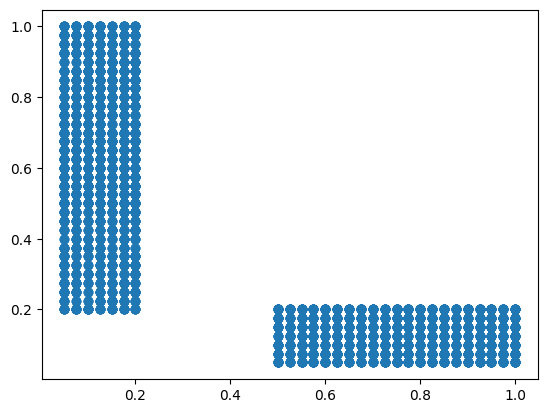

In [30]:

plt.figure()
plt.scatter([s[0] for s in structures["Rect"]], [s[1] for s in structures["Rect"]])
plt.show()


In [12]:
models, losses = find_abstractions(structures, retrain_iterations=4, error_threshold=0.01)

Iteration 1/4: training model for Move on 3072 structures.
Iteration 2/4: training model for Move on 1116 structures.
Iteration 3/4: training model for Move on 1008 structures.
Iteration 4/4: training model for Move on 1093 structures.
Trained model for Move. Final train loss: 0.004788574581551883
Iteration 1/4: training model for Rect on 4608 structures.
Iteration 2/4: training model for Rect on 577 structures.
Iteration 3/4: training model for Rect on 267 structures.
Iteration 4/4: training model for Rect on 297 structures.
Trained model for Rect. Final train loss: 0.004358021449297667
Iteration 1/4: training model for Union(Move, Rect) on 1024 structures.
Iteration 2/4: training model for Union(Move, Rect) on 25 structures.
Iteration 3/4: training model for Union(Move, Rect) on 1 structures.
Iteration 4/4: training model for Union(Move, Rect) on 1 structures.
Trained model for Union(Move, Rect). Final train loss: 0.005639910697937012
Iteration 1/4: training model for Union(Move, Mov

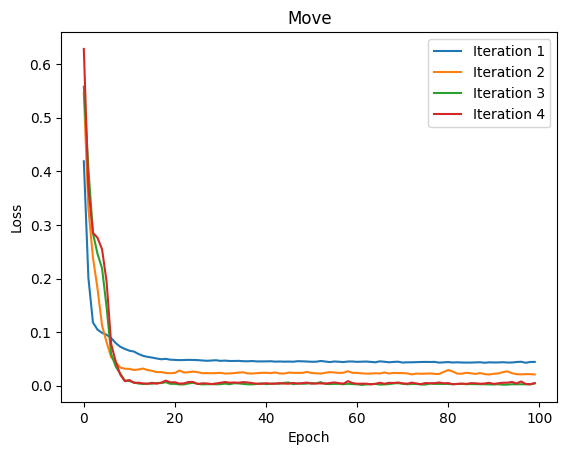

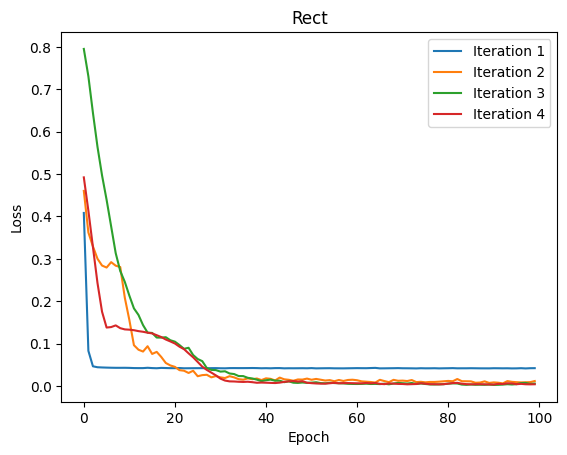

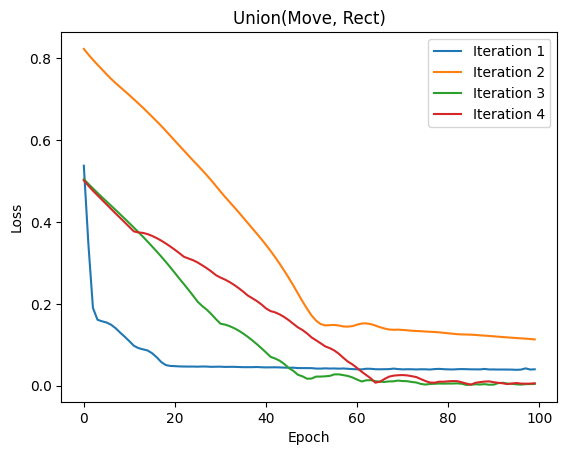

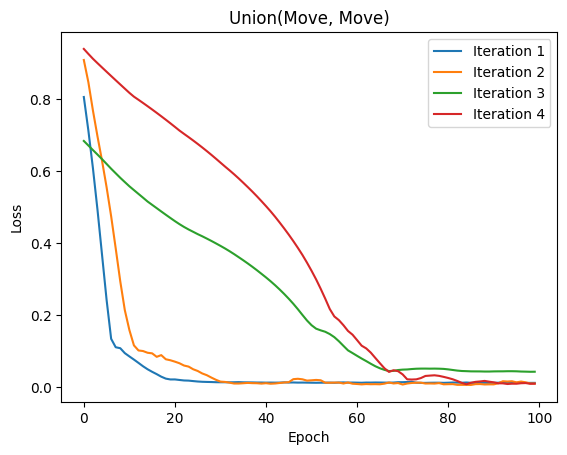

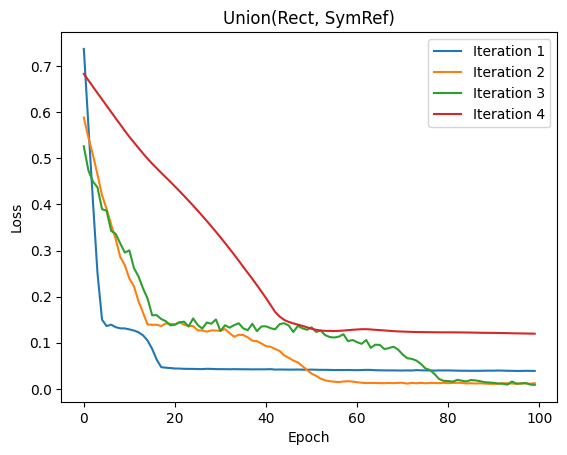

In [13]:

for structure_name, loss_list in losses.items():
    plt.figure()

    for i in range(len(loss_list)):
        plt.plot(loss_list[i], label=f"Iteration {i+1}")

    plt.legend()
    plt.title(structure_name)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

plt.show()


In [35]:
import ipywidgets as widgets
import plotly.graph_objects as go
from IPython.display import display

# Dropdown for selecting structure
structure_dropdown = widgets.Dropdown(
    options=list(losses.keys()),
    description="Structure:",
    layout=widgets.Layout(width='50%')
)

# Output area for interactive plot
output = widgets.Output()

# Function to update plot
def plot_loss_curve(structure_name):
    fig = go.Figure()
    for i, loss_curve in enumerate(losses[structure_name]):
        fig.add_trace(go.Scatter(
            y=loss_curve,
            mode='lines',
            name=f'Retrain {i+1}'
        ))
    fig.update_layout(
        title=f"Loss Curve for {structure_name}",
        xaxis_title="Epoch",
        yaxis_title="Loss",
        height=400,
        width=700
    )
    return fig

# Event listener for dropdown change
def on_dropdown_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        output.clear_output()
        with output:
            fig = plot_loss_curve(change['new'])
            fig.show()

# Hook up dropdown to function
structure_dropdown.observe(on_dropdown_change)

# Display UI
display(structure_dropdown, output)

# Trigger once to show default
output.clear_output()
with output:
    fig = plot_loss_curve(structure_dropdown.value)
    fig.show()

Dropdown(description='Structure:', layout=Layout(width='50%'), options=('Rect', 'Move', 'Union(Rect, SymRef)')…

Output()

In [38]:
threshold = 0.01  # error threshold
structure_dropdown = widgets.Dropdown(options=list(models.keys()), description="Structure:")
output = widgets.Output()

def compute_projection_and_error(structure_name):
    model = models[structure_name]
    parameters = structures[structure_name]

    valid_indices = [i for i, val in enumerate(parameters[0]) if isinstance(val, float)]
    if not valid_indices:
        return None

    float_params = [[p[i] for p in parameters] for i in valid_indices]
    data = torch.tensor(float_params, dtype=torch.float32).T  # shape [N, D]

    model.eval()
    with torch.no_grad():
        enc, recon = model(data)
        error = torch.max(torch.abs(recon - data), dim=-1)[0]
        well_explained = error < threshold

    df = pd.DataFrame(data.numpy(), columns=[f"param_{i}" for i in range(data.shape[1])])
    df["error"] = error.numpy()
    df["well_explained"] = well_explained.numpy()
    df["x"] = df.iloc[:, 0]
    df["y"] = df.iloc[:, 1] if data.shape[1] > 1 else 0.0
    return df

def update_plot(change):
    name = change["new"]
    df = compute_projection_and_error(name)
    output.clear_output()
    with output:
        if df is None:
            print("Structure has no float parameters.")
            return

        scatter = px.scatter(
            df, x="x", y="y",
            color="well_explained",
            hover_data=df.columns,
            color_discrete_map={True: "green", False: "red"},
            title=f"{name} – reconstruction quality"
        )

        error_line = px.line(
            df.sort_values("error").reset_index(),
            y="error",
            title=f"{name} – sorted reconstruction error"
        )

        scatter.show()
        error_line.show()

structure_dropdown.observe(update_plot, names='value')
display(structure_dropdown, output)

# Trigger first draw
structure_dropdown.value = structure_dropdown.options[0]

Dropdown(description='Structure:', options=('Rect', 'Move', 'Union(Rect, SymRef)'), value='Rect')

Output()

In [39]:
abs_dataset = integrate_abstractions(dataset, models, error_threshold=0.03)

In [40]:
abs_dataset

 ...]

In [45]:
from IPython.display import display, Markdown
index = 1
display(Markdown("### Original DSL Program"))
print(dataset[index])
#show_boxes(dataset[index].get_box_list())

### Original DSL Program

Union(
    Union(
        Move(
            Rect(
                0.100,
                0.950
            ),
            -0.288,
            0.562
        ),
        Rect(
            0.675,
            0.175
        )
    ),
    SymRef(
        Move(
            Rect(
                0.200,
                0.550
            ),
            0.238,
            -0.363
        ),
        x
    )
)


In [46]:

display(Markdown("### After Abstraction"))
print(abs_dataset[index])
#show_boxes(abs_dataset[index].get_box_list())

### After Abstraction

Union(
    Union(
        Move(
            Rect(
                0.100,
                0.950
            ),
            -0.288,
            0.562
        ),
        Rect(
            0.675,
            0.175
        )
    ),
    SymRef(
        Move(
            Rect(
                0.200,
                0.550
            ),
            0.238,
            -0.363
        ),
        x
    )
)


In [47]:
def count_nodes(shape):
    if not isinstance(shape, Shape):
        return 1
    _, args = shape.param_tuple()
    return 1 + sum(count_nodes(arg) for arg in args)

print("Original node count:", count_nodes(dataset[index]))
print("Abstracted node count:", count_nodes(abs_dataset[index]))

Original node count: 19
Abstracted node count: 19


In [48]:
from abstractions.dsl.abstraction import Abstraction

def contains_abstraction(shape):
    """
    Recursively checks whether a shape program contains an Abstraction node.
    """
    if isinstance(shape, Abstraction):
        return True
    if not isinstance(shape, Shape):
        return False
    _, args = shape.param_tuple()
    return any(contains_abstraction(arg) for arg in args)

In [49]:
abstracted_indices = [i for i, shape in enumerate(abs_dataset) if contains_abstraction(shape)]

print(f"{len(abstracted_indices)} / {len(abs_dataset)} shapes were abstracted")
print("First few abstracted indices:", abstracted_indices[:10])

26 / 1536 shapes were abstracted
First few abstracted indices: [1040, 1048, 1060, 1087, 1092, 1117, 1140, 1162, 1177, 1184]


In [50]:
import ipywidgets as widgets
from IPython.display import display, Markdown
import matplotlib.pyplot as plt

# Assuming contains_abstraction() and count_nodes() are defined as before

# Find indices with abstraction
abstracted_indices = [i for i, shape in enumerate(abs_dataset) if contains_abstraction(shape)]

# Prepare compression data
compression_data = []
for i in abstracted_indices:
    before = count_nodes(dataset[i])
    after = count_nodes(abs_dataset[i])
    compression_data.append((i, before, after, before - after))

# Sort by compression amount descending
compression_data.sort(key=lambda x: x[3], reverse=True)

# Dropdown widget to select index
dropdown = widgets.Dropdown(
    options=[(f"Index {i} | Δ={delta}", i) for i, _, _, delta in compression_data],
    description="Shape Index:"
)

output = widgets.Output()

def show_comparison(idx):
    output.clear_output()
    with output:
        display(Markdown(f"### Shape Index: {idx}"))
        before = dataset[idx]
        after = abs_dataset[idx]

        print("Original DSL Tree:")
        print_tree(before)

        print("\nAbstracted DSL Tree:")
        print_tree(after)

        print(f"\nNode count before: {count_nodes(before)}")
        print(f"Node count after: {count_nodes(after)}")

        # Show geometry
        fig, axs = plt.subplots(1, 2, figsize=(10, 5))
        axs[0].set_title("Original")
        show_boxes(before.get_box_list())
        axs[1].set_title("Abstracted")
        show_boxes(after.get_box_list())

        plt.show()

dropdown.observe(lambda change: show_comparison(change['new']), names='value')

display(dropdown, output)

# Trigger initial display
if compression_data:
    show_comparison(compression_data[0][0])
else:
    print("No abstracted shapes found.")

Dropdown(description='Shape Index:', options=(('Index 1040 | Δ=7', 1040), ('Index 1048 | Δ=7', 1048), ('Index …

Output()